
# MVP — Estabilidade e Capabilidade de Processos Industriais

## Objetivo

Desenvolver um pipeline de dados em ambiente cloud para coleta, armazenamento, tratamento, modelagem e análise de dados de qualidade de um processo industrial, permitindo avaliar sua estabilidade estatística e sua capacidade de atender aos limites de especificação estabelecidos.

## Problema

Em processos industriais, a conformidade individual das medições com os limites de especificação não garante que o processo esteja estatisticamente estável ou possua capacidade adequada para manter esse desempenho ao longo do tempo.

Variações na dispersão, deslocamentos da média ou alterações no comportamento temporal podem aumentar o risco de produção fora das especificações.

O MVP busca avaliar esse comportamento por meio de Controle Estatístico de Processo e indicadores de capacidade e performance.

## Perguntas do MVP

1. O processo apresenta comportamento estatisticamente estável?
2. O processo possui capacidade suficiente para atender aos limites de especificação?
3. Qual é a diferença entre a capacidade potencial e o desempenho global observado?
4. A deterioração do processo está mais relacionada à variabilidade ou ao deslocamento da média?
5. Existem alterações relevantes entre a Fase I e a Fase II?
6. Os indicadores de curto e longo prazo apresentam diferenças relevantes?

## Tecnologias Utilizadas

- Databricks Free Edition
- Apache Spark / PySpark
- Delta Lake
- Python
- Pandas
- Matplotlib


## Fonte e Coleta dos Dados

O conjunto de dados utilizado no MVP foi o **Piston Rings**, disponibilizado no pacote `qcc` da linguagem R.

A base contém medições do diâmetro interno de anéis de pistão utilizados em motores automotivos. Os dados estão organizados em 40 subgrupos, com 5 medições em cada subgrupo, totalizando 200 observações.

A estrutura original é composta pelas variáveis:

- `diameter`: diâmetro medido do anel;
- `sample`: identificação do subgrupo;
- `trial`: indicador utilizado para diferenciar as fases do estudo.

Os 25 primeiros subgrupos, correspondentes a 125 medições, compõem a Fase I. Os 15 subgrupos seguintes, correspondentes a 75 medições, compõem a Fase II.

A Fase I é utilizada como referência para caracterização do comportamento inicial do processo e estabelecimento dos limites de controle. A Fase II contém observações posteriores utilizadas para monitorar possíveis alterações no processo.

A documentação do conjunto de dados referencia Montgomery (1991), *Introduction to Statistical Quality Control*, como origem do exemplo.

### Processo de coleta

Os dados foram obtidos em formato CSV a partir de uma fonte pública e posteriormente carregados manualmente no Databricks Free Edition.

Após o upload, os registros foram persistidos em uma tabela Delta denominada:

`workspace.default.bronze_piston_rings`

A camada Bronze preservou a estrutura próxima à fonte original, permitindo que as transformações posteriores fossem realizadas sem alterar os dados de entrada.

### Licença

O conjunto é distribuído como parte do pacote `qcc`, disponibilizado sob licença GPL (>= 2).

In [0]:
# Leitura da tabela Bronze
df_bronze = spark.table("workspace.default.bronze_piston_rings")

# Quantidade total de registros
total_registros = df_bronze.count()

print(f"Total de registros na camada Bronze: {total_registros}")

# Visualização inicial dos dados
display(df_bronze.limit(10))

Total de registros na camada Bronze: 200


Unique_id,diameter,sample,trial
Id _1,74.03,1,true
Id _2,74.002,1,true
Id _3,74.019,1,true
Id _4,73.992,1,true
Id _5,74.008,1,true
Id _6,73.995,2,true
Id _7,73.992,2,true
Id _8,74.001,2,true
Id _9,74.011,2,true
Id _10,74.004,2,true


In [0]:
from pyspark.sql import functions as F

# 1. Estrutura da tabela
print("SCHEMA DA TABELA")
df_bronze.printSchema()

# 2. Valores nulos por coluna
print("\nVALORES NULOS")
df_bronze.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_bronze.columns
]).show()

# 3. Registros duplicados
total = df_bronze.count()
total_distintos = df_bronze.distinct().count()

print(f"\nTotal de registros: {total}")
print(f"Registros distintos: {total_distintos}")
print(f"Duplicidades completas: {total - total_distintos}")

# 4. IDs únicos
ids_unicos = df_bronze.select("Unique_id").distinct().count()
print(f"IDs únicos: {ids_unicos}")

# 5. Estatísticas da variável diameter
print("\nESTATÍSTICAS DE DIÂMETRO")
df_bronze.select("diameter").describe().show()

# 6. Validação dos subgrupos
print("\nQUANTIDADE DE MEDIÇÕES POR SUBGRUPO")
display(
    df_bronze
        .groupBy("sample")
        .count()
        .orderBy("sample")
)

# 7. Quantidade de registros por fase original
print("\nDISTRIBUIÇÃO DA VARIÁVEL TRIAL")
df_bronze.groupBy("trial").count().show()

SCHEMA DA TABELA
root
 |-- Unique_id: string (nullable = true)
 |-- diameter: double (nullable = true)
 |-- sample: long (nullable = true)
 |-- trial: boolean (nullable = true)


VALORES NULOS
+---------+--------+------+-----+
|Unique_id|diameter|sample|trial|
+---------+--------+------+-----+
|        0|       0|     0|    0|
+---------+--------+------+-----+


Total de registros: 200
Registros distintos: 200
Duplicidades completas: 0
IDs únicos: 200

ESTATÍSTICAS DE DIÂMETRO
+-------+--------------------+
|summary|            diameter|
+-------+--------------------+
|  count|                 200|
|   mean|   74.00360500000001|
| stddev|0.011417124359628604|
|    min|              73.967|
|    max|              74.036|
+-------+--------------------+


QUANTIDADE DE MEDIÇÕES POR SUBGRUPO


sample,count
1,5
2,5
3,5
4,5
5,5
6,5
7,5
8,5
9,5
10,5



DISTRIBUIÇÃO DA VARIÁVEL TRIAL
+-----+-----+
|trial|count|
+-----+-----+
| true|  125|
|false|   75|
+-----+-----+



In [0]:
from pyspark.sql import functions as F

# Limites de especificação do processo
LSL = 73.95
ALVO = 74.00
USL = 74.05

df_silver = (
    df_bronze

    # Seleção e padronização dos nomes das colunas
    .select(
        F.regexp_replace(F.trim(F.col("Unique_id")), " ", "").alias("id_medicao"),
        F.col("diameter").alias("diametro_mm"),
        F.col("sample").cast("int").alias("subgrupo"),
        F.col("trial")
    )

    # Transformação da variável booleana trial em uma informação mais clara
    .withColumn(
        "fase",
        F.when(F.col("trial") == True, "Fase I")
         .otherwise("Fase II")
    )

    # Inclusão dos limites de especificação
    .withColumn("lsl", F.lit(LSL))
    .withColumn("alvo", F.lit(ALVO))
    .withColumn("usl", F.lit(USL))

    # Classificação individual da medição
    .withColumn(
        "status_especificacao",
        F.when(
            (F.col("diametro_mm") >= F.col("lsl")) &
            (F.col("diametro_mm") <= F.col("usl")),
            "OK"
        ).otherwise("NOK")
    )

    # trial não será mais necessário após termos criado a fase
    .drop("trial")
)

display(df_silver.limit(10))

id_medicao,diametro_mm,subgrupo,fase,lsl,alvo,usl,status_especificacao
Id_1,74.03,1,Fase I,73.95,74.0,74.05,OK
Id_2,74.002,1,Fase I,73.95,74.0,74.05,OK
Id_3,74.019,1,Fase I,73.95,74.0,74.05,OK
Id_4,73.992,1,Fase I,73.95,74.0,74.05,OK
Id_5,74.008,1,Fase I,73.95,74.0,74.05,OK
Id_6,73.995,2,Fase I,73.95,74.0,74.05,OK
Id_7,73.992,2,Fase I,73.95,74.0,74.05,OK
Id_8,74.001,2,Fase I,73.95,74.0,74.05,OK
Id_9,74.011,2,Fase I,73.95,74.0,74.05,OK
Id_10,74.004,2,Fase I,73.95,74.0,74.05,OK


In [0]:
# Validação da camada Silver

print(f"Total de registros na Silver: {df_silver.count()}")

print("\nDistribuição por fase:")
df_silver.groupBy("fase").count().show()

print("\nDistribuição por status de especificação:")
df_silver.groupBy("status_especificacao").count().show()

print("\nVerificação dos subgrupos:")
df_silver.groupBy("subgrupo").count().orderBy("subgrupo").show(40)

Total de registros na Silver: 200

Distribuição por fase:
+-------+-----+
|   fase|count|
+-------+-----+
| Fase I|  125|
|Fase II|   75|
+-------+-----+


Distribuição por status de especificação:
+--------------------+-----+
|status_especificacao|count|
+--------------------+-----+
|                  OK|  200|
+--------------------+-----+


Verificação dos subgrupos:
+--------+-----+
|subgrupo|count|
+--------+-----+
|       1|    5|
|       2|    5|
|       3|    5|
|       4|    5|
|       5|    5|
|       6|    5|
|       7|    5|
|       8|    5|
|       9|    5|
|      10|    5|
|      11|    5|
|      12|    5|
|      13|    5|
|      14|    5|
|      15|    5|
|      16|    5|
|      17|    5|
|      18|    5|
|      19|    5|
|      20|    5|
|      21|    5|
|      22|    5|
|      23|    5|
|      24|    5|
|      25|    5|
|      26|    5|
|      27|    5|
|      28|    5|
|      29|    5|
|      30|    5|
|      31|    5|
|      32|    5|
|      33|    5|
|      34|    5|

In [0]:
# Persistência da camada Silver como tabela Delta

(
    df_silver
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.default.silver_piston_rings")
)

print("Tabela Silver criada com sucesso.")

Tabela Silver criada com sucesso.


In [0]:
# Leitura da Silver já persistida no Databricks

df_silver_persistida = spark.table(
    "workspace.default.silver_piston_rings"
)

print(
    f"Registros na tabela Silver persistida: "
    f"{df_silver_persistida.count()}"
)

display(df_silver_persistida.limit(10))

Registros na tabela Silver persistida: 200


id_medicao,diametro_mm,subgrupo,fase,lsl,alvo,usl,status_especificacao
Id_1,74.03,1,Fase I,73.95,74.0,74.05,OK
Id_2,74.002,1,Fase I,73.95,74.0,74.05,OK
Id_3,74.019,1,Fase I,73.95,74.0,74.05,OK
Id_4,73.992,1,Fase I,73.95,74.0,74.05,OK
Id_5,74.008,1,Fase I,73.95,74.0,74.05,OK
Id_6,73.995,2,Fase I,73.95,74.0,74.05,OK
Id_7,73.992,2,Fase I,73.95,74.0,74.05,OK
Id_8,74.001,2,Fase I,73.95,74.0,74.05,OK
Id_9,74.011,2,Fase I,73.95,74.0,74.05,OK
Id_10,74.004,2,Fase I,73.95,74.0,74.05,OK


In [0]:
from pyspark.sql import functions as F

df_gold = (
    df_silver_persistida

    .groupBy("subgrupo", "fase")

    .agg(
        F.count("*").alias("qtd_medicoes"),
        F.avg("diametro_mm").alias("media_diametro_mm"),
        F.min("diametro_mm").alias("min_diametro_mm"),
        F.max("diametro_mm").alias("max_diametro_mm"),
        F.stddev_samp("diametro_mm").alias("desvio_padrao_mm"),

        F.first("lsl").alias("lsl"),
        F.first("alvo").alias("alvo"),
        F.first("usl").alias("usl")
    )

    .withColumn(
        "amplitude_mm",
        F.col("max_diametro_mm") - F.col("min_diametro_mm")
    )

    .orderBy("subgrupo")
)

display(df_gold)

subgrupo,fase,qtd_medicoes,media_diametro_mm,min_diametro_mm,max_diametro_mm,desvio_padrao_mm,lsl,alvo,usl,amplitude_mm
1,Fase I,5,74.0102,73.992,74.03,0.014771594362152706,73.95,74.0,74.05,0.0379999999999967
2,Fase I,5,74.0006,73.992,74.011,0.007503332592915267,73.95,74.0,74.05,0.018999999999991246
3,Fase I,5,74.00800000000001,73.988,74.024,0.014747881203753909,73.95,74.0,74.05,0.036000000000001364
4,Fase I,5,74.003,73.993,74.015,0.009082951062293993,73.95,74.0,74.05,0.02200000000000557
5,Fase I,5,74.00340000000001,73.989,74.015,0.01221883791528126,73.95,74.0,74.05,0.02599999999999625
6,Fase I,5,73.9956,73.985,74.009,0.008706319543871903,73.95,74.0,74.05,0.02400000000000091
7,Fase I,5,74.0,73.994,74.006,0.005522680508591695,73.95,74.0,74.05,0.012000000000000455
8,Fase I,5,73.9968,73.985,74.015,0.012255610959881473,73.95,74.0,74.05,0.030000000000001137
9,Fase I,5,74.0042,73.995,74.009,0.00554075807087704,73.95,74.0,74.05,0.013999999999995794
10,Fase I,5,73.998,73.99,74.007,0.006284902544991002,73.95,74.0,74.05,0.017000000000010118


In [0]:
# Validação da camada Gold

print(f"Total de subgrupos na Gold: {df_gold.count()}")

print("\nDistribuição por fase:")
df_gold.groupBy("fase").count().show()

print("\nQuantidade de medições por subgrupo:")
df_gold.groupBy("qtd_medicoes").count().show()

print("\nResumo das médias e amplitudes:")
df_gold.select(
    "media_diametro_mm",
    "amplitude_mm"
).describe().show()

Total de subgrupos na Gold: 40

Distribuição por fase:
+-------+-----+
|   fase|count|
+-------+-----+
| Fase I|   25|
|Fase II|   15|
+-------+-----+


Quantidade de medições por subgrupo:
+------------+-----+
|qtd_medicoes|count|
+------------+-----+
|           5|   40|
+------------+-----+


Resumo das médias e amplitudes:
+-------+--------------------+--------------------+
|summary|   media_diametro_mm|        amplitude_mm|
+-------+--------------------+--------------------+
|  count|                  40|                  40|
|   mean|   74.00360500000001|0.023425000000000296|
| stddev|0.007166086440436719| 0.00802524063062681|
|    min|   73.99019999999999|0.008000000000009777|
|    max|   74.02340000000001| 0.04399999999999693|
+-------+--------------------+--------------------+



In [0]:
(
    df_gold
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.default.gold_subgroup_statistics")
)

print("Tabela Gold criada com sucesso.")

Tabela Gold criada com sucesso.


In [0]:
df_gold_persistida = spark.table(
    "workspace.default.gold_subgroup_statistics"
)

print(
    f"Subgrupos na Gold persistida: "
    f"{df_gold_persistida.count()}"
)

display(df_gold_persistida.limit(10))

Subgrupos na Gold persistida: 40


subgrupo,fase,qtd_medicoes,media_diametro_mm,min_diametro_mm,max_diametro_mm,desvio_padrao_mm,lsl,alvo,usl,amplitude_mm
1,Fase I,5,74.0102,73.992,74.03,0.014771594362152706,73.95,74.0,74.05,0.0379999999999967
2,Fase I,5,74.0006,73.992,74.011,0.007503332592915267,73.95,74.0,74.05,0.018999999999991246
3,Fase I,5,74.00800000000001,73.988,74.024,0.014747881203753909,73.95,74.0,74.05,0.036000000000001364
4,Fase I,5,74.003,73.993,74.015,0.009082951062293993,73.95,74.0,74.05,0.02200000000000557
5,Fase I,5,74.00340000000001,73.989,74.015,0.01221883791528126,73.95,74.0,74.05,0.02599999999999625
6,Fase I,5,73.9956,73.985,74.009,0.008706319543871903,73.95,74.0,74.05,0.02400000000000091
7,Fase I,5,74.0,73.994,74.006,0.005522680508591695,73.95,74.0,74.05,0.012000000000000455
8,Fase I,5,73.9968,73.985,74.015,0.012255610959881473,73.95,74.0,74.05,0.030000000000001137
9,Fase I,5,74.0042,73.995,74.009,0.00554075807087704,73.95,74.0,74.05,0.013999999999995794
10,Fase I,5,73.998,73.99,74.007,0.006284902544991002,73.95,74.0,74.05,0.017000000000010118


In [0]:
from pyspark.sql import functions as F

# Seleciona somente os subgrupos da Fase I
df_fase1 = df_gold_persistida.filter(
    F.col("fase") == "Fase I"
)

# Calcula a média das médias e a média das amplitudes
resumo_fase1 = (
    df_fase1
    .agg(
        F.avg("media_diametro_mm").alias("x_barra_barra"),
        F.avg("amplitude_mm").alias("r_barra")
    )
    .first()
)

x_barra_barra = resumo_fase1["x_barra_barra"]
r_barra = resumo_fase1["r_barra"]

print(f"Média geral da Fase I (X̄̄): {x_barra_barra:.6f} mm")
print(f"Amplitude média da Fase I (R̄): {r_barra:.6f} mm")

Média geral da Fase I (X̄̄): 74.001176 mm
Amplitude média da Fase I (R̄): 0.022760 mm


In [0]:
# Constantes da carta X̄-R para subgrupos de tamanho n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# Limites da carta X̄
lic_xbar = x_barra_barra - A2 * r_barra
lc_xbar = x_barra_barra
lsc_xbar = x_barra_barra + A2 * r_barra

# Limites da carta R
lic_r = D3 * r_barra
lc_r = r_barra
lsc_r = D4 * r_barra

print("CARTA X̄")
print(f"LIC: {lic_xbar:.6f} mm")
print(f"LC : {lc_xbar:.6f} mm")
print(f"LSC: {lsc_xbar:.6f} mm")

print("\nCARTA R")
print(f"LIC: {lic_r:.6f} mm")
print(f"LC : {lc_r:.6f} mm")
print(f"LSC: {lsc_r:.6f} mm")

CARTA X̄
LIC: 73.988043 mm
LC : 74.001176 mm
LSC: 74.014309 mm

CARTA R
LIC: 0.000000 mm
LC : 0.022760 mm
LSC: 0.048115 mm


In [0]:
df_controle = (
    df_gold_persistida

    # Limites da carta X̄
    .withColumn("lic_xbar", F.lit(lic_xbar))
    .withColumn("lc_xbar", F.lit(lc_xbar))
    .withColumn("lsc_xbar", F.lit(lsc_xbar))

    # Limites da carta R
    .withColumn("lic_r", F.lit(lic_r))
    .withColumn("lc_r", F.lit(lc_r))
    .withColumn("lsc_r", F.lit(lsc_r))

    # Verificação da média do subgrupo
    .withColumn(
        "status_xbar",
        F.when(
            (F.col("media_diametro_mm") < F.col("lic_xbar")) |
            (F.col("media_diametro_mm") > F.col("lsc_xbar")),
            "FORA DE CONTROLE"
        ).otherwise("SOB CONTROLE")
    )

    # Verificação da amplitude do subgrupo
    .withColumn(
        "status_r",
        F.when(
            (F.col("amplitude_mm") < F.col("lic_r")) |
            (F.col("amplitude_mm") > F.col("lsc_r")),
            "FORA DE CONTROLE"
        ).otherwise("SOB CONTROLE")
    )

    # Diagnóstico combinado
    .withColumn(
        "status_processo",
        F.when(
            (F.col("status_xbar") == "FORA DE CONTROLE") |
            (F.col("status_r") == "FORA DE CONTROLE"),
            "FORA DE CONTROLE"
        ).otherwise("SOB CONTROLE")
    )

    .orderBy("subgrupo")
)

display(
    df_controle.select(
        "subgrupo",
        "fase",
        "media_diametro_mm",
        "amplitude_mm",
        "status_xbar",
        "status_r",
        "status_processo"
    )
)

subgrupo,fase,media_diametro_mm,amplitude_mm,status_xbar,status_r,status_processo
1,Fase I,74.0102,0.0379999999999967,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
2,Fase I,74.0006,0.018999999999991246,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
3,Fase I,74.00800000000001,0.036000000000001364,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
4,Fase I,74.003,0.02200000000000557,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
5,Fase I,74.00340000000001,0.02599999999999625,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
6,Fase I,73.9956,0.02400000000000091,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
7,Fase I,74.0,0.012000000000000455,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
8,Fase I,73.9968,0.030000000000001137,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
9,Fase I,74.0042,0.013999999999995794,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE
10,Fase I,73.998,0.017000000000010118,SOB CONTROLE,SOB CONTROLE,SOB CONTROLE


In [0]:
print("RESULTADO POR FASE")

df_controle.groupBy(
    "fase",
    "status_processo"
).count().orderBy(
    "fase",
    "status_processo"
).show()

print("\nPONTOS FORA DE CONTROLE")

display(
    df_controle
        .filter(F.col("status_processo") == "FORA DE CONTROLE")
        .select(
            "subgrupo",
            "fase",
            "media_diametro_mm",
            "amplitude_mm",
            "status_xbar",
            "status_r"
        )
        .orderBy("subgrupo")
)

RESULTADO POR FASE
+-------+----------------+-----+
|   fase| status_processo|count|
+-------+----------------+-----+
| Fase I|    SOB CONTROLE|   25|
|Fase II|FORA DE CONTROLE|    3|
|Fase II|    SOB CONTROLE|   12|
+-------+----------------+-----+


PONTOS FORA DE CONTROLE


subgrupo,fase,media_diametro_mm,amplitude_mm,status_xbar,status_r
37,Fase II,74.0166,0.019000000000005457,FORA DE CONTROLE,SOB CONTROLE
38,Fase II,74.0196,0.024999999999991473,FORA DE CONTROLE,SOB CONTROLE
39,Fase II,74.02340000000001,0.022999999999996135,FORA DE CONTROLE,SOB CONTROLE


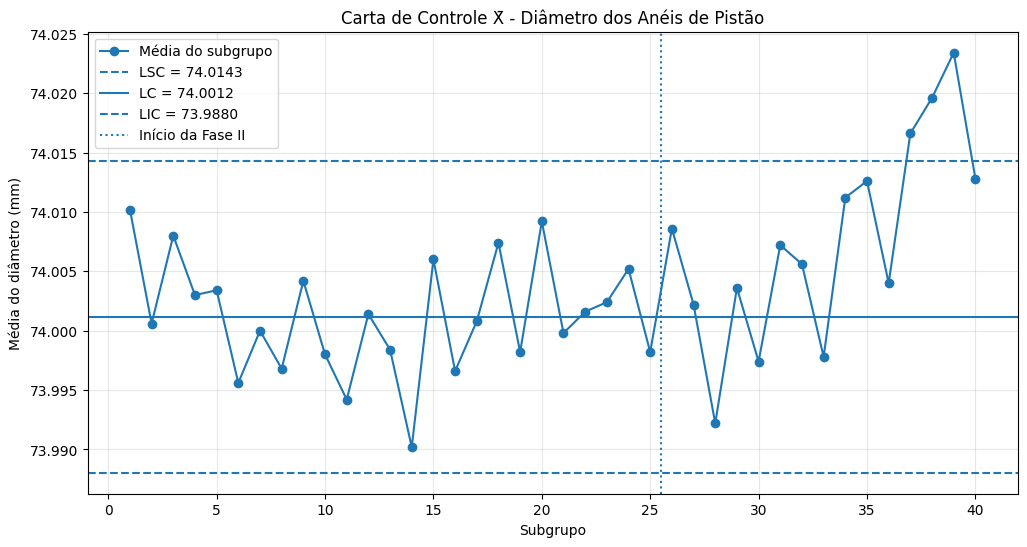

In [0]:
import matplotlib.pyplot as plt

# Converte apenas os 40 registros Gold para Pandas para visualização
pdf_controle = (
    df_controle
    .select(
        "subgrupo",
        "fase",
        "media_diametro_mm",
        "status_xbar"
    )
    .orderBy("subgrupo")
    .toPandas()
)

plt.figure(figsize=(12, 6))

# Médias dos subgrupos
plt.plot(
    pdf_controle["subgrupo"],
    pdf_controle["media_diametro_mm"],
    marker="o",
    label="Média do subgrupo"
)

# Limites calculados a partir da Fase I
plt.axhline(
    y=lsc_xbar,
    linestyle="--",
    label=f"LSC = {lsc_xbar:.4f}"
)

plt.axhline(
    y=lc_xbar,
    linestyle="-",
    label=f"LC = {lc_xbar:.4f}"
)

plt.axhline(
    y=lic_xbar,
    linestyle="--",
    label=f"LIC = {lic_xbar:.4f}"
)

# Separação entre Fase I e Fase II
plt.axvline(
    x=25.5,
    linestyle=":",
    label="Início da Fase II"
)

plt.xlabel("Subgrupo")
plt.ylabel("Média do diâmetro (mm)")
plt.title("Carta de Controle X̄ - Diâmetro dos Anéis de Pistão")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

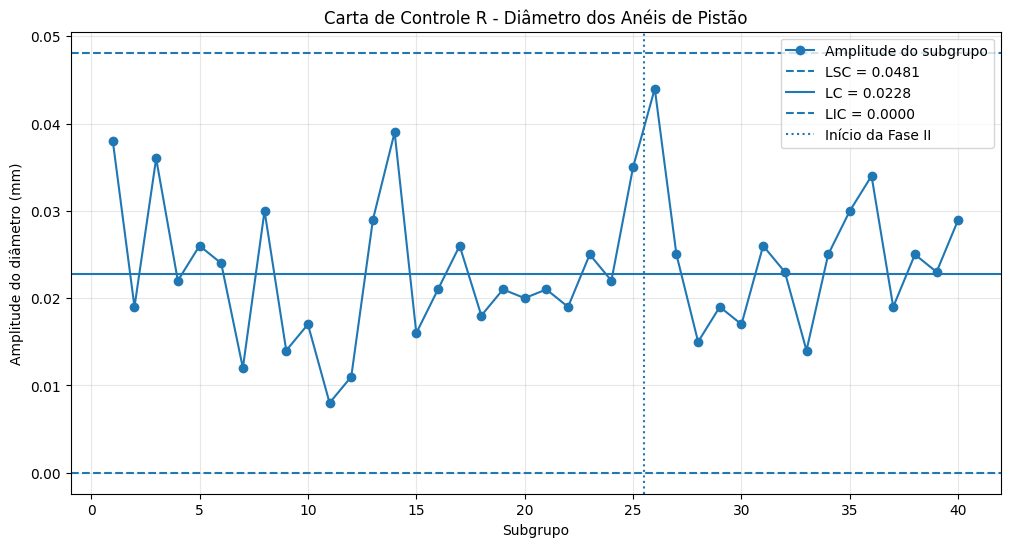

In [0]:
import matplotlib.pyplot as plt

pdf_r = (
    df_controle
    .select(
        "subgrupo",
        "fase",
        "amplitude_mm",
        "status_r"
    )
    .orderBy("subgrupo")
    .toPandas()
)

plt.figure(figsize=(12, 6))

plt.plot(
    pdf_r["subgrupo"],
    pdf_r["amplitude_mm"],
    marker="o",
    label="Amplitude do subgrupo"
)

plt.axhline(
    y=lsc_r,
    linestyle="--",
    label=f"LSC = {lsc_r:.4f}"
)

plt.axhline(
    y=lc_r,
    linestyle="-",
    label=f"LC = {lc_r:.4f}"
)

plt.axhline(
    y=lic_r,
    linestyle="--",
    label=f"LIC = {lic_r:.4f}"
)

plt.axvline(
    x=25.5,
    linestyle=":",
    label="Início da Fase II"
)

plt.xlabel("Subgrupo")
plt.ylabel("Amplitude do diâmetro (mm)")
plt.title("Carta de Controle R - Diâmetro dos Anéis de Pistão")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [0]:
# Especificações
LSL = 73.95
ALVO = 74.00
USL = 74.05

# Constante d2 para subgrupos de tamanho n = 5
d2 = 2.326

# Estimativa da variabilidade de curto prazo (within)
sigma_within = r_barra / d2

# Cp
cp = (USL - LSL) / (6 * sigma_within)

# Componentes do Cpk
cpu = (USL - x_barra_barra) / (3 * sigma_within)
cpl = (x_barra_barra - LSL) / (3 * sigma_within)

# Cpk = pior lado do processo
cpk = min(cpu, cpl)

print(f"Sigma within estimado: {sigma_within:.6f} mm")
print(f"Cp : {cp:.3f}")
print(f"Cpu: {cpu:.3f}")
print(f"Cpl: {cpl:.3f}")
print(f"Cpk: {cpk:.3f}")

Sigma within estimado: 0.009785 mm
Cp : 1.703
Cpu: 1.663
Cpl: 1.743
Cpk: 1.663


In [0]:
# Dados individuais somente da Fase I
df_medicoes_fase1 = df_silver_persistida.filter(
    F.col("fase") == "Fase I"
)

# Média global e desvio-padrão overall da Fase I
resumo_overall = (
    df_medicoes_fase1
    .agg(
        F.avg("diametro_mm").alias("media_overall"),
        F.stddev_samp("diametro_mm").alias("sigma_overall")
    )
    .first()
)

media_overall = resumo_overall["media_overall"]
sigma_overall = resumo_overall["sigma_overall"]

# Pp
pp = (USL - LSL) / (6 * sigma_overall)

# Componentes do Ppk
ppu = (USL - media_overall) / (3 * sigma_overall)
ppl = (media_overall - LSL) / (3 * sigma_overall)

# Ppk
ppk = min(ppu, ppl)

print(f"Média overall Fase I: {media_overall:.6f} mm")
print(f"Sigma overall: {sigma_overall:.6f} mm")
print(f"Pp : {pp:.3f}")
print(f"Ppu: {ppu:.3f}")
print(f"Ppl: {ppl:.3f}")
print(f"Ppk: {ppk:.3f}")

Média overall Fase I: 74.001176 mm
Sigma overall: 0.010070 mm
Pp : 1.655
Ppu: 1.616
Ppl: 1.694
Ppk: 1.616


In [0]:
# Resumo estatístico por fase

resumo_fases = (
    df_silver_persistida
    .groupBy("fase")
    .agg(
        F.count("*").alias("qtd_medicoes"),
        F.avg("diametro_mm").alias("media_mm"),
        F.stddev_samp("diametro_mm").alias("desvio_padrao_mm"),
        F.min("diametro_mm").alias("min_mm"),
        F.max("diametro_mm").alias("max_mm")
    )
    .orderBy("fase")
)

display(resumo_fases)

fase,qtd_medicoes,media_mm,desvio_padrao_mm,min_mm,max_mm
Fase I,125,74.00117599999999,0.010069968126293079,73.967,74.03
Fase II,75,74.00765333333337,0.01241129970471669,73.985,74.036


In [0]:
# Dados individuais da Fase II
df_medicoes_fase2 = df_silver_persistida.filter(
    F.col("fase") == "Fase II"
)

resumo_fase2 = (
    df_medicoes_fase2
    .agg(
        F.avg("diametro_mm").alias("media_fase2"),
        F.stddev_samp("diametro_mm").alias("sigma_overall_fase2")
    )
    .first()
)

media_fase2 = resumo_fase2["media_fase2"]
sigma_overall_fase2 = resumo_fase2["sigma_overall_fase2"]

# Pp e Ppk da Fase II
pp_fase2 = (USL - LSL) / (6 * sigma_overall_fase2)

ppu_fase2 = (USL - media_fase2) / (3 * sigma_overall_fase2)
ppl_fase2 = (media_fase2 - LSL) / (3 * sigma_overall_fase2)

ppk_fase2 = min(ppu_fase2, ppl_fase2)

print(f"Média Fase II: {media_fase2:.6f} mm")
print(f"Sigma overall Fase II: {sigma_overall_fase2:.6f} mm")
print(f"Pp Fase II : {pp_fase2:.3f}")
print(f"Ppu Fase II: {ppu_fase2:.3f}")
print(f"Ppl Fase II: {ppl_fase2:.3f}")
print(f"Ppk Fase II: {ppk_fase2:.3f}")

Média Fase II: 74.007653 mm
Sigma overall Fase II: 0.012411 mm
Pp Fase II : 1.343
Ppu Fase II: 1.137
Ppl Fase II: 1.548
Ppk Fase II: 1.137


In [0]:
dados_comparacao = [
    (
        "Fase I",
        74.001176,
        0.010070,
        1.655,
        1.616,
        0,
        25,
        0
    ),
    (
        "Fase II",
        74.007653,
        0.012411,
        1.343,
        1.137,
        3,
        15,
        0
    )
]

colunas = [
    "fase",
    "media_mm",
    "sigma_overall_mm",
    "pp",
    "ppk",
    "subgrupos_fora_controle",
    "total_subgrupos",
    "medicoes_nok"
]

df_comparacao = spark.createDataFrame(
    dados_comparacao,
    colunas
)

display(df_comparacao)

fase,media_mm,sigma_overall_mm,pp,ppk,subgrupos_fora_controle,total_subgrupos,medicoes_nok
Fase I,74.001176,0.01007,1.655,1.616,0,25,0
Fase II,74.007653,0.012411,1.343,1.137,3,15,0


In [0]:
(
    df_comparacao
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.default.gold_phase_comparison")
)

In [0]:
(
    df_controle
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.default.gold_process_control")
)

print("Tabela gold_process_control criada com sucesso.")

Tabela gold_process_control criada com sucesso.


In [0]:
# Métricas gerais de qualidade da camada Bronze

total_registros = df_bronze.count()
registros_distintos = df_bronze.distinct().count()

ids_unicos = (
    df_bronze
    .select("Unique_id")
    .distinct()
    .count()
)

subgrupos_incompletos = (
    df_bronze
    .groupBy("sample")
    .count()
    .filter(F.col("count") != 5)
    .count()
)

resumo_diametro = (
    df_bronze
    .agg(
        F.min("diameter").alias("min_diameter"),
        F.max("diameter").alias("max_diameter")
    )
    .first()
)

print("QUALIDADE DOS DADOS")
print(f"Total de registros: {total_registros}")
print(f"Duplicidades completas: {total_registros - registros_distintos}")
print(f"IDs duplicados: {total_registros - ids_unicos}")
print(f"Subgrupos incompletos: {subgrupos_incompletos}")
print(f"Diâmetro mínimo: {resumo_diametro['min_diameter']} mm")
print(f"Diâmetro máximo: {resumo_diametro['max_diameter']} mm")

QUALIDADE DOS DADOS
Total de registros: 200
Duplicidades completas: 0
IDs duplicados: 0
Subgrupos incompletos: 0
Diâmetro mínimo: 73.967 mm
Diâmetro máximo: 74.036 mm


In [0]:
# Completude por atributo

metricas_completude = []

for coluna in df_bronze.columns:

    nulos = (
        df_bronze
        .filter(F.col(coluna).isNull())
        .count()
    )

    preenchidos = total_registros - nulos

    completude_pct = (
        preenchidos / total_registros
    ) * 100

    metricas_completude.append(
        (
            coluna,
            total_registros,
            nulos,
            preenchidos,
            completude_pct
        )
    )

df_completude = spark.createDataFrame(
    metricas_completude,
    [
        "atributo",
        "total_registros",
        "valores_nulos",
        "valores_preenchidos",
        "completude_pct"
    ]
)

display(df_completude)

atributo,total_registros,valores_nulos,valores_preenchidos,completude_pct
Unique_id,200,0,200,100.0
diameter,200,0,200,100.0
sample,200,0,200,100.0
trial,200,0,200,100.0


In [0]:
dados_catalogo = [

    # ---------------- BRONZE ----------------
    (
        "Bronze",
        "bronze_piston_rings",
        "Unique_id",
        "string",
        "Identificador único da medição na fonte original",
        "-",
        "Valor único e não nulo",
        "Campo original do arquivo CSV"
    ),

    (
        "Bronze",
        "bronze_piston_rings",
        "diameter",
        "double",
        "Diâmetro medido do anel de pistão",
        "mm",
        "Valor numérico positivo; observado entre 73.967 e 74.036 mm",
        "Campo original do arquivo CSV"
    ),

    (
        "Bronze",
        "bronze_piston_rings",
        "sample",
        "bigint",
        "Identificador do subgrupo de amostragem",
        "-",
        "Inteiros de 1 a 40; 5 medições por subgrupo",
        "Campo original do arquivo CSV"
    ),

    (
        "Bronze",
        "bronze_piston_rings",
        "trial",
        "boolean",
        "Indicador da fase original do estudo",
        "-",
        "TRUE ou FALSE",
        "Campo original do arquivo CSV"
    ),

    # ---------------- SILVER ----------------
    (
        "Silver",
        "silver_piston_rings",
        "id_medicao",
        "string",
        "Identificador padronizado da medição",
        "-",
        "Valor único e não nulo",
        "Derivado de Unique_id após remoção de espaços"
    ),

    (
        "Silver",
        "silver_piston_rings",
        "diametro_mm",
        "double",
        "Diâmetro medido do anel de pistão",
        "mm",
        "Valor numérico positivo; especificação de 73.95 a 74.05 mm",
        "Renomeação da coluna diameter"
    ),

    (
        "Silver",
        "silver_piston_rings",
        "subgrupo",
        "integer",
        "Identificador do subgrupo de amostragem",
        "-",
        "Inteiros de 1 a 40",
        "Conversão da coluna sample"
    ),

    (
        "Silver",
        "silver_piston_rings",
        "fase",
        "string",
        "Fase utilizada na análise estatística",
        "-",
        "Fase I ou Fase II",
        "trial = TRUE → Fase I; trial = FALSE → Fase II"
    ),

    (
        "Silver",
        "silver_piston_rings",
        "lsl",
        "double",
        "Limite inferior de especificação",
        "mm",
        "73.95",
        "Valor de especificação do processo"
    ),

    (
        "Silver",
        "silver_piston_rings",
        "alvo",
        "double",
        "Valor nominal da característica",
        "mm",
        "74.00",
        "Valor nominal do processo"
    ),

    (
        "Silver",
        "silver_piston_rings",
        "usl",
        "double",
        "Limite superior de especificação",
        "mm",
        "74.05",
        "Valor de especificação do processo"
    ),

    (
        "Silver",
        "silver_piston_rings",
        "status_especificacao",
        "string",
        "Classificação individual da medição frente à especificação",
        "-",
        "OK ou NOK",
        "OK quando LSL <= diametro_mm <= USL"
    ),

    # ---------------- GOLD ----------------
    (
        "Gold",
        "gold_subgroup_statistics",
        "subgrupo",
        "integer",
        "Identificador do subgrupo analisado",
        "-",
        "Inteiros de 1 a 40",
        "Agrupamento da tabela Silver"
    ),

    (
        "Gold",
        "gold_subgroup_statistics",
        "fase",
        "string",
        "Fase correspondente ao subgrupo",
        "-",
        "Fase I ou Fase II",
        "Mantido da tabela Silver"
    ),

    (
        "Gold",
        "gold_subgroup_statistics",
        "qtd_medicoes",
        "bigint",
        "Quantidade de medições existentes no subgrupo",
        "-",
        "Esperado: 5",
        "Contagem das medições da Silver"
    ),

    (
        "Gold",
        "gold_subgroup_statistics",
        "media_diametro_mm",
        "double",
        "Média do diâmetro das cinco medições do subgrupo",
        "mm",
        "Valor numérico",
        "AVG(diametro_mm) por subgrupo"
    ),

    (
        "Gold",
        "gold_subgroup_statistics",
        "min_diametro_mm",
        "double",
        "Menor diâmetro observado no subgrupo",
        "mm",
        "Valor numérico",
        "MIN(diametro_mm) por subgrupo"
    ),

    (
        "Gold",
        "gold_subgroup_statistics",
        "max_diametro_mm",
        "double",
        "Maior diâmetro observado no subgrupo",
        "mm",
        "Valor numérico",
        "MAX(diametro_mm) por subgrupo"
    ),

    (
        "Gold",
        "gold_subgroup_statistics",
        "desvio_padrao_mm",
        "double",
        "Desvio-padrão amostral das medições do subgrupo",
        "mm",
        "Valor maior ou igual a zero",
        "STDDEV_SAMP(diametro_mm) por subgrupo"
    ),

    (
        "Gold",
        "gold_subgroup_statistics",
        "amplitude_mm",
        "double",
        "Amplitude das medições do subgrupo",
        "mm",
        "Valor maior ou igual a zero",
        "max_diametro_mm - min_diametro_mm"
    )
]

colunas_catalogo = [
    "camada",
    "tabela",
    "atributo",
    "tipo",
    "descricao",
    "unidade",
    "dominio_esperado",
    "origem_transformacao"
]

df_catalogo = spark.createDataFrame(
    dados_catalogo,
    colunas_catalogo
)

display(df_catalogo)

camada,tabela,atributo,tipo,descricao,unidade,dominio_esperado,origem_transformacao
Bronze,bronze_piston_rings,Unique_id,string,Identificador único da medição na fonte original,-,Valor único e não nulo,Campo original do arquivo CSV
Bronze,bronze_piston_rings,diameter,double,Diâmetro medido do anel de pistão,mm,Valor numérico positivo; observado entre 73.967 e 74.036 mm,Campo original do arquivo CSV
Bronze,bronze_piston_rings,sample,bigint,Identificador do subgrupo de amostragem,-,Inteiros de 1 a 40; 5 medições por subgrupo,Campo original do arquivo CSV
Bronze,bronze_piston_rings,trial,boolean,Indicador da fase original do estudo,-,TRUE ou FALSE,Campo original do arquivo CSV
Silver,silver_piston_rings,id_medicao,string,Identificador padronizado da medição,-,Valor único e não nulo,Derivado de Unique_id após remoção de espaços
Silver,silver_piston_rings,diametro_mm,double,Diâmetro medido do anel de pistão,mm,Valor numérico positivo; especificação de 73.95 a 74.05 mm,Renomeação da coluna diameter
Silver,silver_piston_rings,subgrupo,integer,Identificador do subgrupo de amostragem,-,Inteiros de 1 a 40,Conversão da coluna sample
Silver,silver_piston_rings,fase,string,Fase utilizada na análise estatística,-,Fase I ou Fase II,trial = TRUE → Fase I; trial = FALSE → Fase II
Silver,silver_piston_rings,lsl,double,Limite inferior de especificação,mm,73.95,Valor de especificação do processo
Silver,silver_piston_rings,alvo,double,Valor nominal da característica,mm,74.00,Valor nominal do processo


In [0]:
(
    df_catalogo
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.default.data_catalog_mvp")
)

print("Catálogo de dados criado com sucesso.")

Catálogo de dados criado com sucesso.



## Arquitetura da Solução

O MVP foi estruturado em uma arquitetura em camadas, separando os dados de acordo com o seu nível de tratamento e finalidade analítica.

### Bronze

A camada Bronze contém os dados próximos ao formato original da fonte, preservando as informações recebidas no arquivo CSV.

Tabela:
- `bronze_piston_rings`

### Silver

A camada Silver contém os dados tratados e padronizados. Nesta etapa foram realizados:
- padronização dos nomes das colunas;
- tratamento do identificador da medição;
- conversão da variável `trial` em `Fase I` e `Fase II`;
- inclusão dos limites de especificação;
- classificação das medições em OK ou NOK.

Tabela:
- `silver_piston_rings`

### Gold

A camada Gold contém informações derivadas e preparadas para análise estatística e tomada de decisão.

Tabelas:
- `gold_subgroup_statistics`
- `gold_process_control`
- `gold_phase_comparison`

Essas tabelas suportam as análises de estabilidade e capabilidade do processo.


## Linhagem dos Dados

O conjunto de dados utilizado no MVP foi obtido a partir de uma base pública contendo medições de diâmetro de anéis de pistão organizadas em subgrupos de amostragem.

O fluxo dos dados no projeto foi estruturado da seguinte forma:

**Fonte de dados (CSV)**  
↓  
**bronze_piston_rings**  
↓  
**silver_piston_rings**  
↓  
**gold_subgroup_statistics**  
↓  
**gold_process_control**  
↓  
**gold_phase_comparison**

### Fonte → Bronze

O arquivo CSV foi carregado no Databricks e persistido como tabela Delta na camada Bronze, preservando a estrutura original dos dados.

### Bronze → Silver

Nesta transformação foram realizadas:

- padronização dos nomes das colunas;
- limpeza do identificador da medição;
- conversão de `sample` para `subgrupo`;
- conversão da variável booleana `trial` em `Fase I` e `Fase II`;
- inclusão dos limites inferior e superior de especificação e do valor-alvo;
- classificação das medições individuais em OK ou NOK.

### Silver → Gold

A partir das medições tratadas foram construídas tabelas analíticas contendo:

- estatísticas por subgrupo;
- média do diâmetro;
- mínimo e máximo;
- amplitude;
- desvio-padrão;
- limites das cartas de controle;
- classificação dos subgrupos quanto ao controle estatístico;
- indicadores consolidados para comparação entre as fases.

### Utilização Analítica

As tabelas da camada Gold foram utilizadas nas análises de:

- estabilidade do processo por meio das cartas X̄ e R;
- capacidade de curto prazo por meio de Cp e Cpk;
- performance global por meio de Pp e Ppk;
- comparação entre a Fase I e a Fase II.


## Respostas às Perguntas do MVP

### 1. O processo apresenta comportamento estatisticamente estável?

Na Fase I, os 25 subgrupos permaneceram dentro dos limites das cartas X̄ e R, indicando estabilidade estatística segundo os critérios utilizados.

Na Fase II, os subgrupos 37, 38 e 39 ultrapassaram o limite superior da carta X̄. A carta R permaneceu sob controle em todos os subgrupos.

O resultado indica um deslocamento da média do processo na Fase II, sem evidência de aumento anormal da variabilidade intrassubgrupo.

### 2. O processo possui capacidade suficiente para atender aos limites de especificação?

Na Fase I foram obtidos:

- Cp = 1,703
- Cpk = 1,663
- Pp = 1,655
- Ppk = 1,616

Os resultados indicam boa capacidade do processo durante a Fase I, período no qual foi verificada estabilidade estatística. A variabilidade apresentou-se compatível com a faixa de especificação e a média permaneceu próxima ao valor-alvo.

### 3. Qual é a diferença entre a capacidade potencial e o desempenho global observado?

Na Fase I, foram obtidos Cpk = 1,663 e Ppk = 1,616.

A pequena diferença entre os indicadores demonstra que a variabilidade global observada foi apenas ligeiramente superior à variabilidade de curto prazo estimada dentro dos subgrupos.

Isso indica comportamento relativamente consistente entre a variação intrassubgrupo e a variação global do processo durante a Fase I.

### 4. A deterioração observada está mais relacionada à variabilidade ou ao deslocamento da média?

Os resultados indicam principalmente um deslocamento da média do processo.

Na Fase II, os subgrupos 37, 38 e 39 ficaram fora de controle na carta X̄, enquanto todos os subgrupos permaneceram sob controle na carta R.

Além disso, foram obtidos:

- Ppu = 1,137
- Ppl = 1,548

Como Ppu apresentou o menor valor, o limite superior de especificação tornou-se o lado mais crítico do processo.

Dessa forma, a deterioração observada está mais associada ao deslocamento da média em direção ao limite superior de especificação do que a um aumento anormal da variabilidade intrassubgrupo.

### 5. Existem alterações relevantes entre a Fase I e a Fase II?

Sim.

| Indicador | Fase I | Fase II |
|---|---:|---:|
| Média (mm) | 74,0012 | 74,0077 |
| Sigma overall (mm) | 0,0101 | 0,0124 |
| Pp | 1,655 | 1,343 |
| Ppk | 1,616 | 1,137 |
| Subgrupos fora de controle | 0 | 3 |

A Fase II apresentou aumento da média, aumento da variabilidade global e redução dos índices de performance.

Além disso, três subgrupos consecutivos apresentaram médias acima do limite superior de controle da carta X̄, indicando alteração no comportamento do processo em relação à referência estabelecida na Fase I.

### 6. Os indicadores de curto e longo prazo apresentam diferenças relevantes?

Na Fase I, a diferença entre Cpk = 1,663 e Ppk = 1,616 foi pequena.

Esse resultado indica comportamento relativamente consistente entre a variabilidade de curto prazo, estimada dentro dos subgrupos, e a variabilidade global observada ao longo da fase.

Na Fase II, foram identificados sinais de instabilidade estatística. Por esse motivo, Pp e Ppk foram utilizados para descrever o desempenho global observado nessa fase, evitando interpretar Cp e Cpk como representativos da capacidade de um processo estável.

## Principal Resultado

Todas as 200 medições analisadas permaneceram dentro dos limites de especificação de 73,95 mm a 74,05 mm.

Entretanto, o Controle Estatístico de Processo identificou perda de estabilidade na Fase II, com os subgrupos 37, 38 e 39 acima do limite superior da carta X̄.

Ao mesmo tempo, a carta R permaneceu sob controle, indicando que a principal alteração ocorreu no centro do processo e não na variabilidade intrassubgrupo.

Esse resultado demonstra que a conformidade individual das peças não é suficiente, por si só, para assegurar a estabilidade estatística do processo. O acompanhamento conjunto dos limites de especificação, das cartas de controle e dos indicadores de capacidade e performance permite identificar alterações no processo antes mesmo da ocorrência de produtos fora de especificação.


## Conclusão Geral

O MVP teve como objetivo desenvolver um pipeline de dados em ambiente cloud para avaliar a estabilidade e a capacidade de um processo industrial a partir de medições de qualidade.

A solução foi estruturada em camadas Bronze, Silver e Gold no Databricks, permitindo a ingestão, tratamento, padronização, consolidação e análise dos dados. Também foram realizadas verificações de qualidade dos dados, documentação do catálogo e construção da linhagem das transformações.

Na Fase I, o processo apresentou estabilidade estatística nas cartas X̄ e R. Os índices Cp = 1,703, Cpk = 1,663, Pp = 1,655 e Ppk = 1,616 indicaram boa capacidade e desempenho frente aos limites de especificação de 73,95 mm a 74,05 mm.

Na Fase II, apesar de todas as medições permanecerem dentro dos limites de especificação, foram identificados sinais de perda de estabilidade. Os subgrupos 37, 38 e 39 ultrapassaram o limite superior da carta X̄, enquanto a carta R permaneceu sob controle.

Também foi observada redução do Ppk de 1,616 para 1,137 entre as fases, acompanhada de aumento da média e da variabilidade global.

Os resultados indicam que a principal alteração do processo esteve associada ao deslocamento da média em direção ao limite superior de especificação, e não a um aumento anormal da variabilidade dentro dos subgrupos.

Dessa forma, o MVP demonstrou que a avaliação isolada da conformidade do produto não é suficiente para assegurar a estabilidade do processo. A utilização conjunta de Controle Estatístico de Processo e indicadores de capacidade e performance permite identificar alterações no comportamento do processo antes da ocorrência de produtos fora de especificação.


## Autoavaliação

O objetivo principal do MVP foi atingido. Foi possível construir um pipeline de dados em ambiente cloud no Databricks, passando pelas etapas de coleta, persistência, tratamento, modelagem e análise dos dados.

A solução permitiu avaliar tanto a estabilidade estatística quanto a capacidade e a performance do processo analisado. A utilização das cartas X̄ e R possibilitou identificar uma alteração no comportamento do processo durante a Fase II, mesmo sem a ocorrência de medições fora dos limites de especificação.

Também foi possível calcular e interpretar os índices Cp, Cpk, Pp e Ppk, permitindo diferenciar a variabilidade de curto prazo da performance global observada no processo.

Entre as principais dificuldades encontradas estiveram a familiarização inicial com o ambiente Databricks, a estruturação das diferentes camadas do pipeline e a correta interpretação estatística dos indicadores de capacidade e das cartas de controle.

Como limitação, o conjunto de dados utilizado possui poucas variáveis de processo. Dessa forma, foi possível identificar a alteração no comportamento do processo, mas não determinar sua causa.

Como trabalho futuro, o MVP poderia ser ampliado com variáveis de processo, como máquina, operador, turno, temperatura, velocidade ou matéria-prima, permitindo investigar possíveis causas para alterações de estabilidade e capacidade. Também poderiam ser incorporadas regras adicionais de Controle Estatístico de Processo e mecanismos de alerta automático para identificação antecipada de desvios.